# Zero Hunger - SDG 2 : Food Security Risk Analysis
**Student Name:** BHARGAV HATHWAR G  
**SRN:** PES1PG25CA035  
**Project Domain:** Agriculture  
**Goal:** Zero Hunger (SDG 2)  
**Dataset:** Grain Demand Production (USDA / Kaggle)

---

This notebook covers:
1. Data Loading and Cleaning
2. Preprocessing and Feature Engineering
3. Random Forest Classification
4. K-Means Clustering


## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load the Dataset

In [6]:
df = pd.read_csv("GrainDemandProduction.csv")

print("Shape:", df.shape)
df.head(10)


Shape: (151, 6)


,Dataset,Element,Region,Sub-region,Year,Millions of metric tons
0,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,"Asia, Total",2022.0,507.7
1,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,"Asia, Total",2032.0,654.7
2,"Grain food demand, other demand, total demand,...",Food grain demand,Sub-Saharan Africa,Central Africa,2022.0,8.0
3,"Grain food demand, other demand, total demand,...",Food grain demand,Sub-Saharan Africa,Central Africa,2032.0,12.0
4,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,Central and South Asia,2022.0,352.1
5,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,Central and South Asia,2032.0,461.2
6,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,Commonwealth of Independent States,2022.0,19.5
7,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,Commonwealth of Independent States,2032.0,24.5
8,"Grain food demand, other demand, total demand,...",Food grain demand,Sub-Saharan Africa,East Africa,2022.0,49.8
9,"Grain food demand, other demand, total demand,...",Food grain demand,Sub-Saharan Africa,East Africa,2032.0,76.9


In [7]:
# Check basic info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Dataset                  151 non-null    str    
 1   Element                  150 non-null    str    
 2   Region                   150 non-null    str    
 3   Sub-region               150 non-null    str    
 4   Year                     150 non-null    float64
 5   Millions of metric tons  150 non-null    float64
dtypes: float64(2), str(4)
memory usage: 7.2 KB


In [8]:
# Check for null values
df.isnull().sum()


Dataset                    0
Element                    1
Region                     1
Sub-region                 1
Year                       1
Millions of metric tons    1
dtype: int64

## 3. Data Cleaning

In [9]:
# Drop rows where all values are null (blank rows at the end of CSV)
df.dropna(how="all", inplace=True)

# Drop rows where important columns are missing
df.dropna(subset=["Element", "Region", "Year", "Millions of metric tons"], inplace=True)

# Rename the long column name to something simpler
df.rename(columns={"Millions of metric tons": "Value"}, inplace=True)

# Strip extra whitespace from text columns
df["Element"] = df["Element"].str.strip()
df["Region"] = df["Region"].str.strip()
df["Sub-region"] = df["Sub-region"].str.strip()

# Keep only the 5 relevant element types
relevant_elements = [
    "Food grain demand",
    "Other grain demand",
    "Total grain demand",
    "Grain production",
    "Implied additional supply required"
]
df = df[df["Element"].isin(relevant_elements)]
df.reset_index(drop=True, inplace=True)

print("Cleaned data shape:", df.shape)
df.head()


Cleaned data shape: (150, 6)


,Dataset,Element,Region,Sub-region,Year,Value
0,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,"Asia, Total",2022.0,507.7
1,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,"Asia, Total",2032.0,654.7
2,"Grain food demand, other demand, total demand,...",Food grain demand,Sub-Saharan Africa,Central Africa,2022.0,8.0
3,"Grain food demand, other demand, total demand,...",Food grain demand,Sub-Saharan Africa,Central Africa,2032.0,12.0
4,"Grain food demand, other demand, total demand,...",Food grain demand,Asia,Central and South Asia,2022.0,352.1


In [10]:
# Check unique values in key columns
print("Unique Elements:", df["Element"].unique())
print("Unique Regions:", df["Region"].unique())
print("Unique Years:", df["Year"].unique())


Unique Elements: <StringArray>
[                 'Food grain demand',                 'Other grain demand',
                 'Total grain demand',                   'Grain production',
 'Implied additional supply required']
Length: 5, dtype: str
Unique Regions: <StringArray>
[                           'Asia',              'Sub-Saharan Africa',
                  'IFSA Countries', 'Latin America and the Caribbean',
                    'North Africa']
Length: 5, dtype: str
Unique Years: [2022. 2032.]


## 4. Exploratory Data Analysis (EDA)

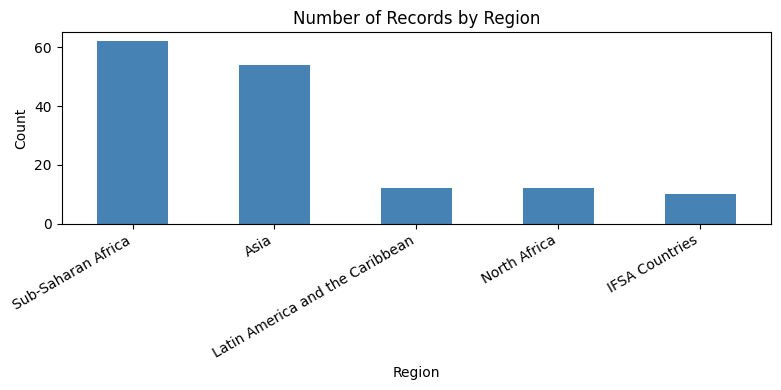

In [11]:
# Bar chart - Number of records per region
plt.figure(figsize=(8, 4))
df["Region"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Number of Records by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


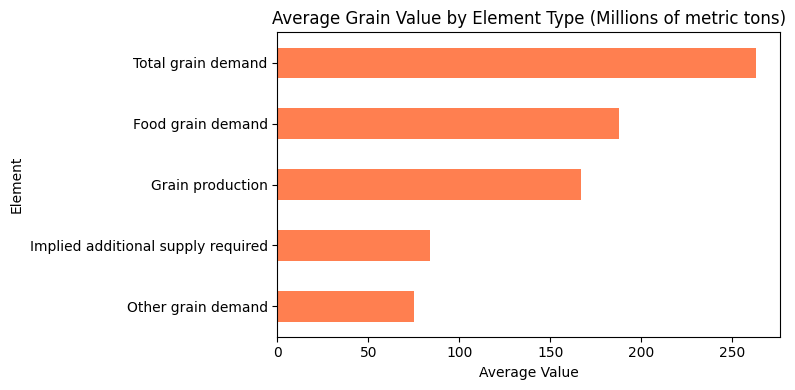

In [12]:
# Average value by element type
plt.figure(figsize=(8, 4))
avg_by_element = df.groupby("Element")["Value"].mean().sort_values()
avg_by_element.plot(kind="barh", color="coral")
plt.title("Average Grain Value by Element Type (Millions of metric tons)")
plt.xlabel("Average Value")
plt.tight_layout()
plt.show()


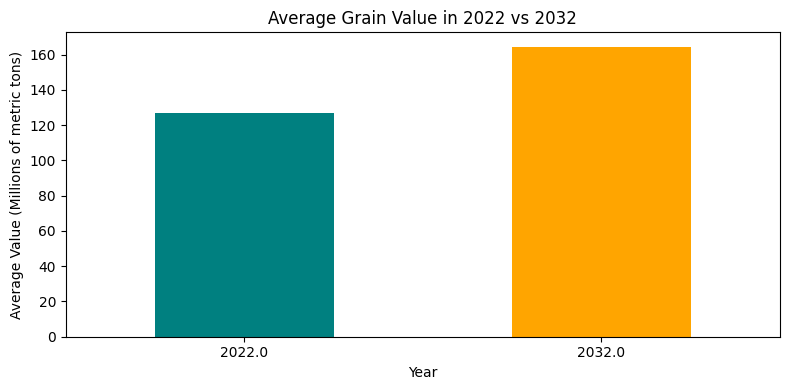

In [13]:
# Comparison of values in 2022 vs 2032
plt.figure(figsize=(8, 4))
year_avg = df.groupby("Year")["Value"].mean()
year_avg.plot(kind="bar", color=["teal", "orange"])
plt.title("Average Grain Value in 2022 vs 2032")
plt.xlabel("Year")
plt.ylabel("Average Value (Millions of metric tons)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Feature Engineering and Preprocessing

In [14]:
# Pivot the dataset so each Element becomes its own column
# This gives us one row per (Region, Sub-region, Year)
pivot = df.pivot_table(
    index=["Region", "Sub-region", "Year"],
    columns="Element",
    values="Value",
    aggfunc="first"
).reset_index()

pivot.columns.name = None
pivot.columns = [str(c) for c in pivot.columns]

print("Pivoted data shape:", pivot.shape)
pivot.head()


Pivoted data shape: (26, 8)


,Region,Sub-region,Year,Food grain demand,Grain production,Implied additional supply required,Other grain demand,Total grain demand
0,Asia,"Asia, Total",2022.0,507.7,512.7,168.1,173.1,680.8
1,Asia,"Asia, Total",2032.0,654.7,565.5,296.3,207.1,861.9
2,Asia,Central and South Asia,2022.0,352.1,384.9,47.8,80.6,432.7
3,Asia,Central and South Asia,2032.0,461.2,426.4,140.5,105.7,566.9
4,Asia,Commonwealth of Independent States,2022.0,19.5,16.7,29.7,26.9,46.4


In [15]:
# Fill any missing numeric values with column mean
num_cols = [c for c in pivot.columns if c not in ["Region", "Sub-region", "Year"]]
for col in num_cols:
    pivot[col] = pivot[col].fillna(pivot[col].mean())

print("Missing values after fill:")
print(pivot.isnull().sum())


Missing values after fill:
Region                                0
Sub-region                            0
Year                                  0
Food grain demand                     0
Grain production                      0
Implied additional supply required    0
Other grain demand                    0
Total grain demand                    0
dtype: int64


In [16]:
# Create the target label : Food Security Risk Level
# Based on "Implied additional supply required"
# More implied supply needed = higher food insecurity risk

implied_col = "Implied additional supply required"

q33 = pivot[implied_col].quantile(0.33)
q66 = pivot[implied_col].quantile(0.66)

def assign_risk(val):
    if val <= q33:
        return "Low"
    elif val <= q66:
        return "Medium"
    else:
        return "High"

pivot["Risk_Label"] = pivot[implied_col].apply(assign_risk)

print("Risk label distribution:")
print(pivot["Risk_Label"].value_counts())


Risk label distribution:
Risk_Label
High      9
Low       9
Medium    8
Name: count, dtype: int64


In [17]:
# Encode Region and Sub-region as numeric values for ML
le_region = LabelEncoder()
le_subregion = LabelEncoder()

pivot["Region_enc"] = le_region.fit_transform(pivot["Region"])
pivot["Sub-region_enc"] = le_subregion.fit_transform(pivot["Sub-region"])

print("Region encoding mapping:")
for i, name in enumerate(le_region.classes_):
    print(f"  {i} -> {name}")


Region encoding mapping:
  0 -> Asia
  1 -> IFSA Countries
  2 -> Latin America and the Caribbean
  3 -> North Africa
  4 -> Sub-Saharan Africa


In [18]:
# Final model-ready data
print("Final dataset shape:", pivot.shape)
pivot.head()


Final dataset shape: (26, 11)


,Region,Sub-region,Year,Food grain demand,Grain production,Implied additional supply required,Other grain demand,Total grain demand,Risk_Label,Region_enc,Sub-region_enc
0,Asia,"Asia, Total",2022.0,507.7,512.7,168.1,173.1,680.8,High,0,0
1,Asia,"Asia, Total",2032.0,654.7,565.5,296.3,207.1,861.9,High,0,0
2,Asia,Central and South Asia,2022.0,352.1,384.9,47.8,80.6,432.7,Medium,0,2
3,Asia,Central and South Asia,2032.0,461.2,426.4,140.5,105.7,566.9,High,0,2
4,Asia,Commonwealth of Independent States,2022.0,19.5,16.7,29.7,26.9,46.4,Low,0,3


## 6. Random Forest Classification

In [19]:
# Define features and target
feature_cols = [
    "Food grain demand",
    "Grain production",
    "Other grain demand",
    "Total grain demand",
    "Implied additional supply required",
    "Region_enc",
    "Sub-region_enc",
    "Year"
]
feature_cols = [c for c in feature_cols if c in pivot.columns]

X = pivot[feature_cols]
y = pivot["Risk_Label"]

# Encode target labels
le_label = LabelEncoder()
y_enc = le_label.fit_transform(y)

print("Features used:", feature_cols)
print("Class labels:", le_label.classes_)


Features used: ['Food grain demand', 'Grain production', 'Other grain demand', 'Total grain demand', 'Implied additional supply required', 'Region_enc', 'Sub-region_enc', 'Year']
Class labels: ['High' 'Low' 'Medium']


In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 20
Testing samples: 6


In [21]:
# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")


Random Forest Accuracy: 100.00%


In [22]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_label.classes_))


Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       1.00      1.00      1.00         1
      Medium       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



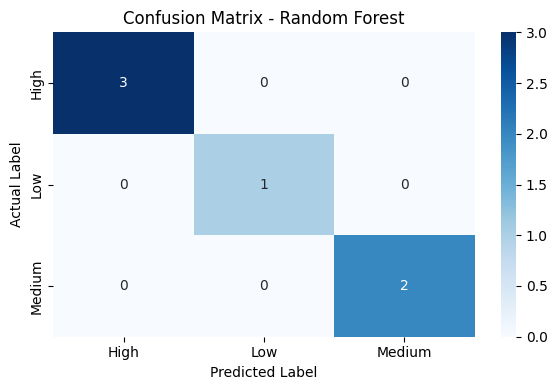

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_label.classes_,
            yticklabels=le_label.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()


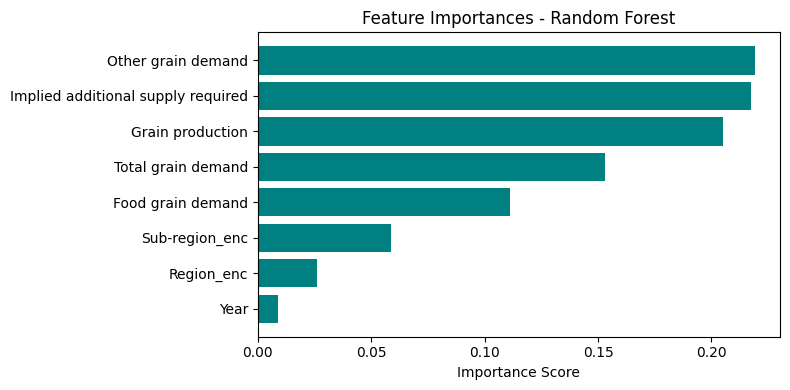

In [24]:
# Feature Importance
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="teal")
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


## 7. K-Means Clustering

In [25]:
# Features for clustering (only numeric grain-related columns)
cluster_features = [
    "Food grain demand",
    "Grain production",
    "Other grain demand",
    "Total grain demand",
    "Implied additional supply required"
]
cluster_features = [c for c in cluster_features if c in pivot.columns]

X_cluster = pivot[cluster_features]
print("Clustering features:", cluster_features)


Clustering features: ['Food grain demand', 'Grain production', 'Other grain demand', 'Total grain demand', 'Implied additional supply required']


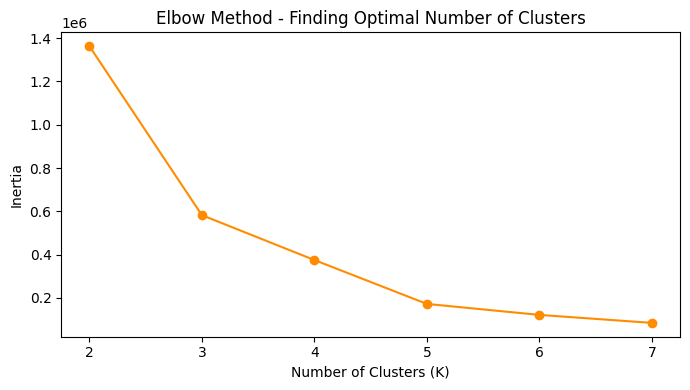

In [26]:
# Elbow Method to find the best number of clusters
inertias = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o", color="darkorange")
plt.title("Elbow Method - Finding Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()


In [27]:
# Train K-Means with K=3 (Low, Medium, High hunger risk groups)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pivot["Cluster"] = kmeans.fit_predict(X_cluster)

print("Cluster distribution:")
print(pivot["Cluster"].value_counts().sort_index())


Cluster distribution:
Cluster
0    20
1     2
2     4
Name: count, dtype: int64


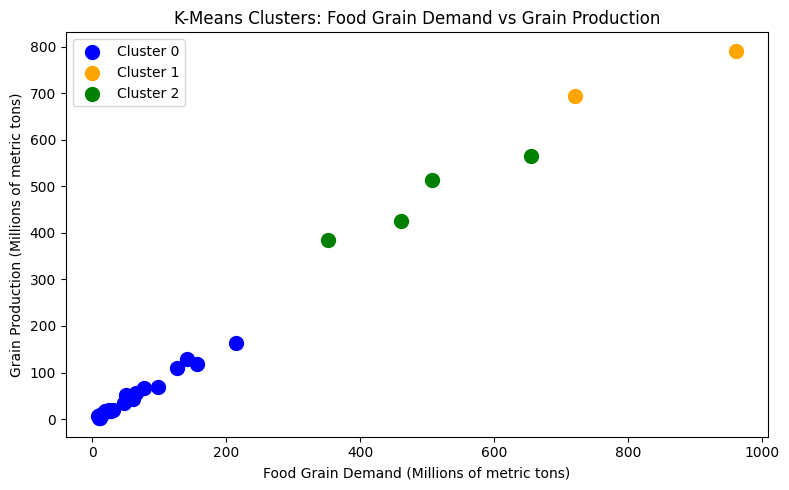

In [28]:
# Scatter plot : Food Grain Demand vs Grain Production
plt.figure(figsize=(8, 5))
colors = ["blue", "orange", "green"]

for cluster_id in sorted(pivot["Cluster"].unique()):
    subset = pivot[pivot["Cluster"] == cluster_id]
    plt.scatter(
        subset["Food grain demand"],
        subset["Grain production"],
        label=f"Cluster {cluster_id}",
        color=colors[cluster_id],
        s=100
    )

plt.title("K-Means Clusters: Food Grain Demand vs Grain Production")
plt.xlabel("Food Grain Demand (Millions of metric tons)")
plt.ylabel("Grain Production (Millions of metric tons)")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
# Cluster summary - average of each feature per cluster
cluster_summary = pivot.groupby("Cluster")[cluster_features].mean().round(2)
print("Average feature values per cluster:")
cluster_summary


Average feature values per cluster:


,Food grain demand,Grain production,Other grain demand,Total grain demand,Implied additional supply required
Cluster,,,,,
0,61.36,48.32,33.86,95.22,46.90
1,841.70,742.45,357.15,1198.80,456.35
2,493.92,472.38,141.62,635.58,163.18


In [30]:
# Which regions fall in which cluster
cluster_regions = pivot[["Region", "Sub-region", "Year", "Cluster"]].sort_values("Cluster")
print(cluster_regions.to_string(index=False))


                         Region                             Sub-region   Year  Cluster
Latin America and the Caribbean Latin America and the Caribbean, Total 2022.0        0
             Sub-Saharan Africa              Sub-Saharan Africa, Total 2032.0        0
             Sub-Saharan Africa              Sub-Saharan Africa, Total 2022.0        0
             Sub-Saharan Africa                        Southern Africa 2032.0        0
             Sub-Saharan Africa                        Southern Africa 2022.0        0
             Sub-Saharan Africa                            East Africa 2032.0        0
             Sub-Saharan Africa                            East Africa 2022.0        0
             Sub-Saharan Africa                         Central Africa 2032.0        0
             Sub-Saharan Africa                         Central Africa 2022.0        0
                   North Africa                    North Africa, Total 2032.0        0
                   North Africa            